<a href="https://colab.research.google.com/github/varshabonkur/Image-Caption-Generator-Deep-Learning/blob/main/Image_Caption_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Caption Generator Using Deep Learning

## Objective
To automatically generate meaningful captions for images using a CNN-LSTM Encoder-Decoder architecture trained on the Flickr8k dataset.

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from PIL import Image

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

100%|██████████| 1.04G/1.04G [00:05<00:00, 186MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1"

print(os.listdir(dataset_path))

['captions.txt', 'Images']


In [ ]:
image_path = dataset_path + "/Images"

print("Number of images:", len(os.listdir(image_path)))

Number of images: 8091


In [ ]:
for file in os.listdir(dataset_path):
    print(file)

captions.txt
Images


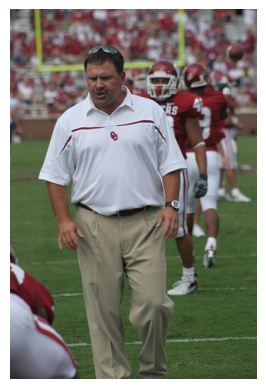

In [ ]:
#for displaying 1 image from the dataset
from PIL import Image
import matplotlib.pyplot as plt

sample = os.listdir(image_path)[0]

img = Image.open(os.path.join(image_path, sample))

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
image_path = os.path.join(dataset_path, "Images")

print("Total Images:", len(os.listdir(image_path)))

Total Images: 8091


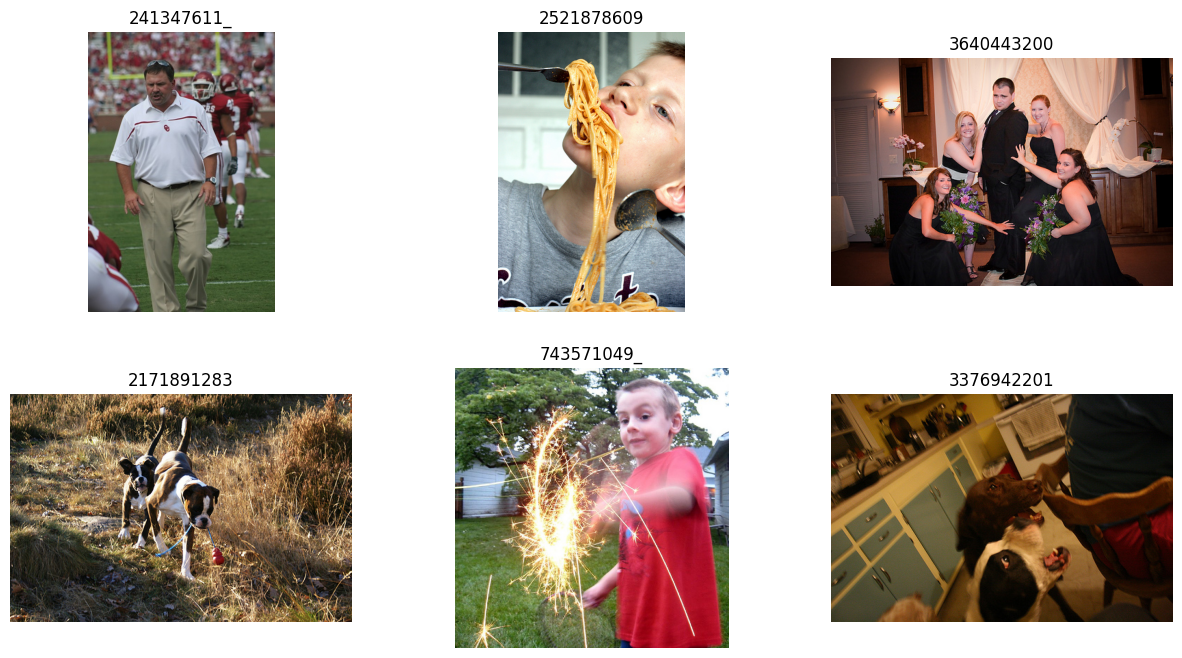

In [ ]:
sample_images = os.listdir(image_path)[:6]

plt.figure(figsize=(15,8))

for i, img_name in enumerate(sample_images):
    img = Image.open(os.path.join(image_path, img_name))
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(img_name[:10])
    plt.axis("off")

plt.show()

In [ ]:
for file in os.listdir(dataset_path):
    print(file)

captions.txt
Images


# Phase 2: Caption Preprocessing

In [15]:
caption_file = os.path.join(dataset_path, "captions.txt")

captions = pd.read_csv(caption_file)

captions.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [16]:
print("Shape:", captions.shape)
print("\nColumns:")
print(captions.columns)

captions.info()

Shape: (40455, 2)

Columns:
Index(['image', 'caption'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40455 entries, 0 to 40454
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   image    40455 non-null  object
 1   caption  40455 non-null  object
dtypes: object(2)
memory usage: 632.2+ KB


In [17]:
#Checking Missing Values
captions.isnull().sum()

,0
image,0
caption,0


In [18]:
#Display Random Captions
captions.sample(10)

,image,caption
11574,2574230252_f5a1382dd4.jpg,The dog walks in the shallow water .
1190,1282392036_5a0328eb86.jpg,A group of people in costume at a renaissance ...
30899,3542425197_2ef81c6051.jpg,Two people perform on a stage with electric gu...
28789,3459419203_cd7c68ce4d.jpg,Two people are in a swimming pool with water s...
36902,466176275_f40d37851e.jpg,Two dogs are chasing each other in a yard .
2692,1481062342_d9e34366c4.jpg,A little girl running down a brighly lit hallw...
6592,2249865945_f432c8e5da.jpg,A small white and grey dog in a jacket standin...
6358,2228022180_9597b2a458.jpg,Little children in school uniforms congregate ...
2045,141139674_246c0f90a1.jpg,A boy hits a baseball with the bat .
23918,3262075846_5695021d84.jpg,A group of opposing players are in the middle ...


In [19]:
#Number of Unique Images
print("Unique Images :", captions["image"].nunique())

Unique Images : 8091


In [20]:
#Captions Per Image
captions.groupby("image").size().value_counts()

,count
5,8091
